# OSM roads — Lyon

Loads the road-noise rasters of the Plan bruit de la Métropole de Lyon (Lden and Ln,
continuous modeled dB, 10 m, EPSG:2154), downloads the OSM drive network for Lyon,
assigns each OSM street segment the dB value sampled from the rasters at the segment
midpoint, classifies the dB values into the 5 noise classes used by the ML pipeline,
computes distance-to-road-category features and exports
`../layers/LYO_noise_streets.gpkg` and `data/osm_roads_noise_class.csv`.

In [1]:
import os
import geopandas as gpd
import osmnx as ox
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## Import and analyse the road-noise rasters

In [2]:
import rasterio

_layers_dir = os.path.join(os.path.dirname(os.path.abspath(os.getcwd())), 'layers')
lden_src = rasterio.open(os.path.join(_layers_dir, 'GL_Rte_Lden.tif'))
ln_src = rasterio.open(os.path.join(_layers_dir, 'GL_Rte_Ln.tif'))

print('Lden CRS:', lden_src.crs, '| res:', lden_src.res, '| nodata:', lden_src.nodata)
print('Ln   CRS:', ln_src.crs, '| res:', ln_src.res, '| nodata:', ln_src.nodata)
RASTER_CRS = lden_src.crs

Lden CRS: EPSG:2154 | res: (10.0, 10.0) | nodata: -9999.0
Ln   CRS: EPSG:2154 | res: (10.0, 10.0) | nodata: -9999.0


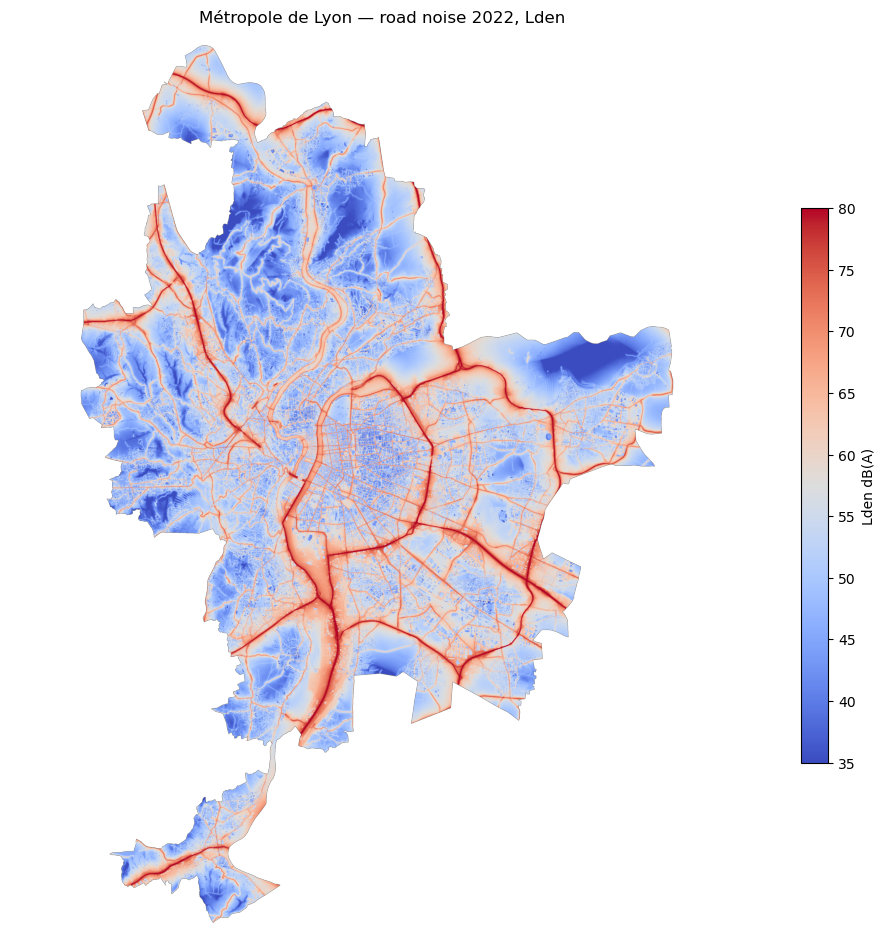

In [3]:
arr = np.ma.masked_equal(lden_src.read(1), lden_src.nodata)
fig, ax = plt.subplots(figsize=(12, 12))
im = ax.imshow(arr, cmap='coolwarm', vmin=35, vmax=80)
plt.colorbar(im, ax=ax, shrink=0.6, label='Lden dB(A)')
ax.set_title('Métropole de Lyon — road noise 2022, Lden')
ax.set_axis_off()
plt.show()

## Roads - OSM

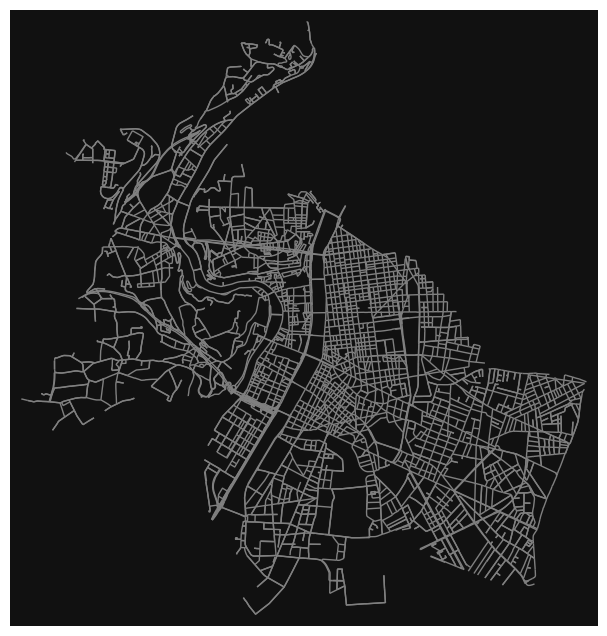

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [4]:
GRAPHML_PATH = os.path.join('data', 'lyon.graphml')
os.makedirs('data', exist_ok=True)

if os.path.exists(GRAPHML_PATH):
    print('Loading cached graph from', GRAPHML_PATH)
    G = ox.load_graphml(GRAPHML_PATH)
else:
    print('Downloading Lyon OSM graph (drive network) ...')
    G = ox.graph_from_place('Lyon, France', network_type='drive')
    ox.save_graphml(G, GRAPHML_PATH)

ox.plot_graph(G, edge_color='gray', node_size=0)

## Prepare graph edges (roads)

In [5]:
nodes, edges = ox.graph_to_gdfs(G)

# Assign a unique segment_id to each edge based on its start and end nodes and its key
edges["segment_id"] = edges.index.map(lambda x: f"{x[0]}_{x[1]}_{x[2]}")
edges['segment_id'].head(10)

# Project edges to the same CRS as the noise-map segments (EPSG:2154 — RGF93 / Lambert-93)
roads = edges[edges.geometry.type == 'LineString'].to_crs(RASTER_CRS)
print('Roads:', len(roads), 'CRS:', roads.crs)

Roads: 8042 CRS: PROJCS["RGF_1993_Lambert_Conformal_Conic",GEOGCS["RGF93 v1",DATUM["Reseau_Geodesique_Francais_1993_v1",SPHEROID["GRS 1980",6378137,298.257222101004,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6171"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4171"]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",46.5],PARAMETER["central_meridian",3],PARAMETER["standard_parallel_1",44],PARAMETER["standard_parallel_2",49],PARAMETER["false_easting",700000],PARAMETER["false_northing",6600000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]


## Check features completeness

In [6]:
for col in ['width', 'maxspeed', 'lanes', 'oneway']:
    if col in roads.columns:
        print(f'Checking {col}..')
        print(roads[col].value_counts(dropna=False).head(20))
    else:
        print(f'{col}: column not present')

Checking width..
width
NaN    7423
6        92
8        80
7        66
3        44
5        44
4        30
10       20
11       16
3.5      14
3.2      13
3.8      12
9        10
12       10
5.2       9
6.4       8
5.7       8
2.8       6
5.1       6
5.6       6
Name: count, dtype: int64
Checking maxspeed..
maxspeed
30            6715
50             817
20             292
NaN            116
[30, 50]        36
[20, 30]        30
70              24
[70, 50]         6
[30, walk]       2
[30, 10]         2
10               1
[25, 20]         1
Name: count, dtype: int64
Checking lanes..
lanes
NaN          4292
2            1884
1            1120
3             370
4             159
[2, 1]         77
[3, 2]         77
5              14
[4, 2]         12
[4, 3]         11
[4, 3, 2]      11
[3, 1]          9
[3, 2, 1]       3
[3, 5]          1
[5, 2]          1
[4, 5]          1
Name: count, dtype: int64
Checking oneway..
oneway
True     4656
False    3386
Name: count, dtype: int64


## Check if road is tunnel

In [7]:
# OSM 'tunnel' values can be strings or lists — mark as tunnel if any value is 'yes'
if 'tunnel' in roads.columns:
    roads['is_tunnel'] = roads['tunnel'].apply(
        lambda v: 1 if v == 'yes' or (isinstance(v, list) and 'yes' in v) else 0
    )
else:
    roads['is_tunnel'] = 0

print(roads['is_tunnel'].value_counts())

is_tunnel
0    7971
1      71
Name: count, dtype: int64


## Filter roads categories

In [8]:
# Filter to only primary and secondary roads
categories = ['living_street','residential','primary','secondary','tertiary','trunk']
roads_filtered = roads[roads['highway'].isin(categories)&
    (roads['is_tunnel'] == 0)]
print(f"Original: {len(roads)}, Filtered: {len(roads_filtered)}")

Original: 8042, Filtered: 7159


## Plot road categories distribution

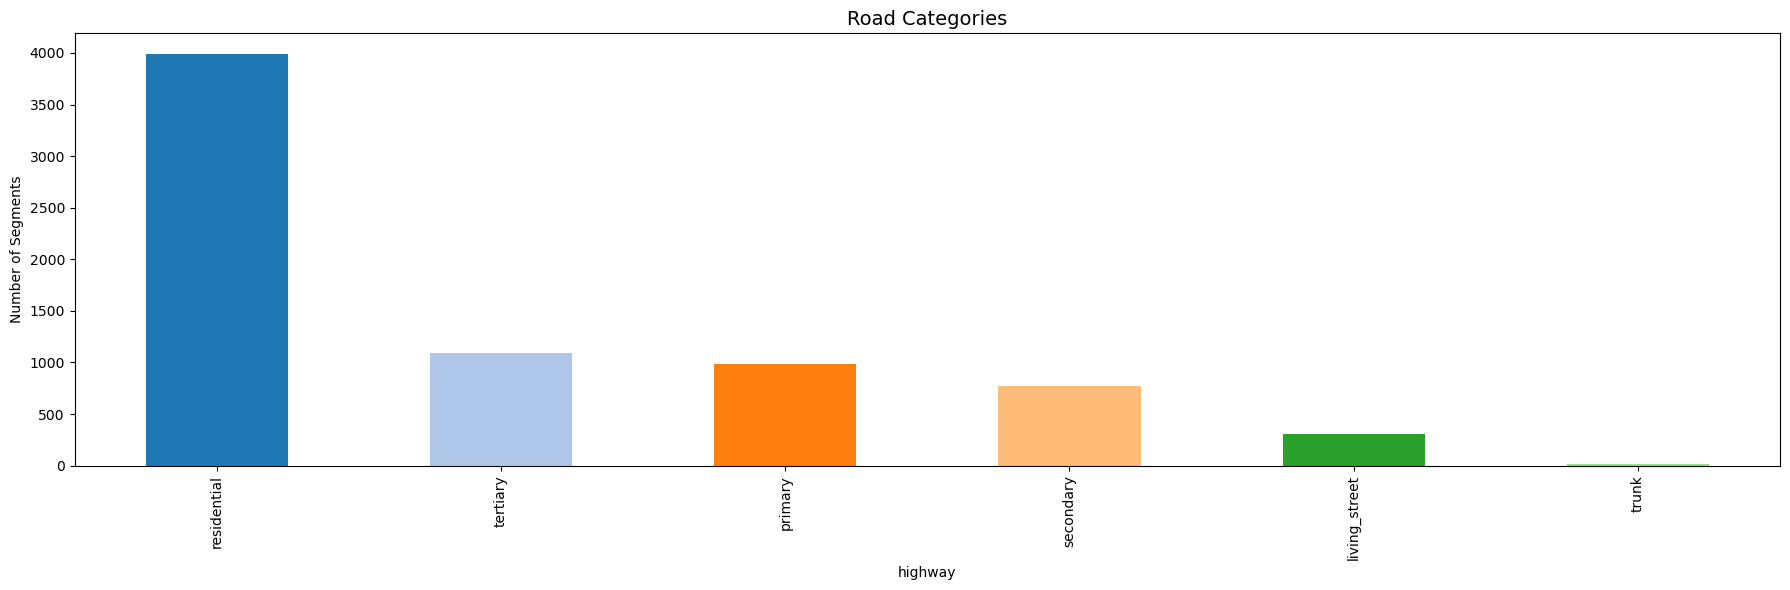

In [9]:
fig, axes = plt.subplots(1, 1, figsize=(18, 6))

class_count = roads_filtered['highway'].value_counts()

class_count.plot(kind='bar', ax=axes, color=plt.cm.tab20.colors[:len(class_count)])
axes.set_title("Road Categories", fontsize=14)
axes.set_ylabel("Number of Segments")
axes.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

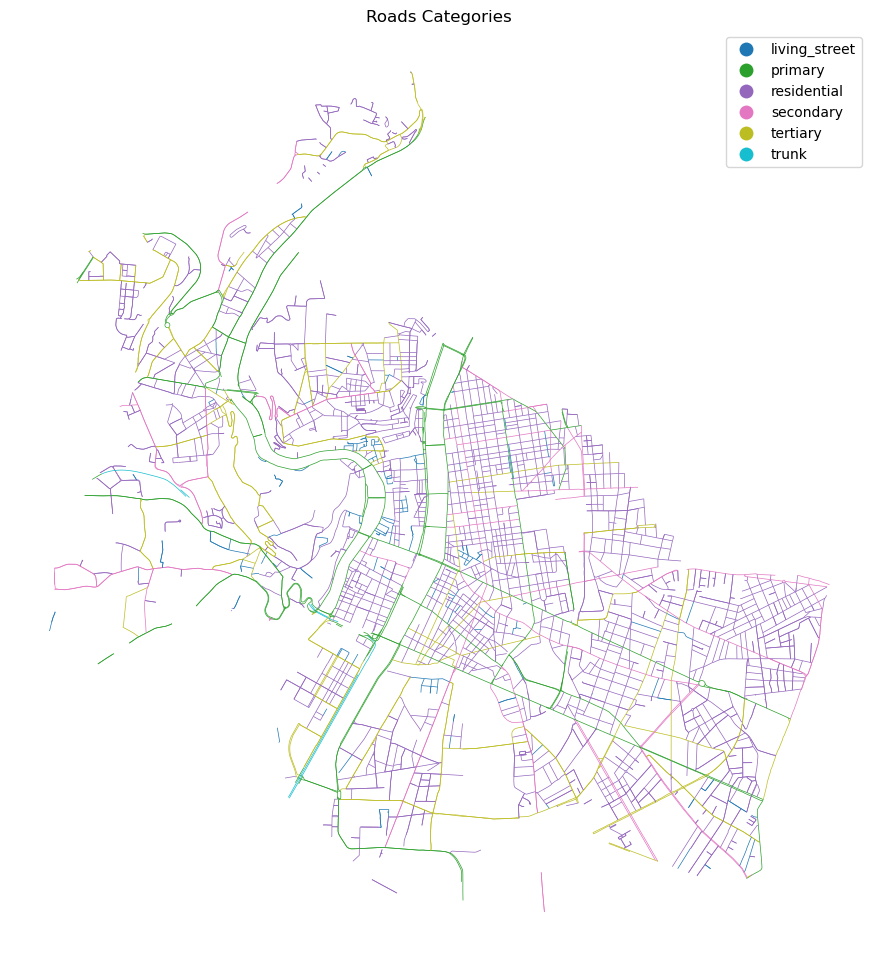

In [10]:
ax = roads_filtered.plot(column='highway', linewidth=0.5, legend=True, figsize=(12, 12))
ax.set_title('Roads Categories')
ax.set_axis_off()

## Assign noise values to each street segment

Each OSM segment gets the raster dB value sampled at its midpoint: `db_day` and
`db_evening` from the Lden raster (no separate day/evening rasters are published),
`db_night` from the Ln raster. With 10 m resolution the raster pixel under the street
axis is the modeled level on the street itself. Midpoints falling on nodata
(outside the Métropole or unmodeled areas) are dropped and counted.

In [11]:
# Midpoint -> raster sampling
noise_roads = roads_filtered.reset_index(drop=True).copy()
midpoints = noise_roads.geometry.interpolate(0.5, normalized=True)
coords = [(p.x, p.y) for p in midpoints]

lden_vals = np.array([v[0] for v in lden_src.sample(coords)], dtype=float)
ln_vals = np.array([v[0] for v in ln_src.sample(coords)], dtype=float)
lden_vals[lden_vals == lden_src.nodata] = np.nan
ln_vals[ln_vals == ln_src.nodata] = np.nan

noise_roads['db_day'] = lden_vals
noise_roads['db_evening'] = lden_vals
noise_roads['db_night'] = ln_vals

noise_cols = ['db_day', 'db_evening', 'db_night']
n_total = len(noise_roads)
noise_roads = noise_roads[noise_roads['db_day'].notna() & noise_roads['db_night'].notna()].copy()
print(f'Segments with noise values: {len(noise_roads)} / {n_total}')
noise_roads[noise_cols].describe()

Segments with noise values: 7159 / 7159


,db_day,db_evening,db_night
count,7159.000000,7159.000000,7159.000000
mean,64.862778,64.862778,54.512495
std,6.336150,6.336150,6.309953
min,41.396999,41.396999,31.284000
25%,60.005001,60.005001,49.665001
50%,63.555000,63.555000,53.214001
75%,70.418499,70.418499,60.032001
max,86.014000,86.014000,75.635002


## Classify noise into 5 classes: <40, 40-50, 50-60, 60-70, >70

In [12]:
# Classify numeric noise dB into 5 classes: 0=<40, 1=40-50, 2=50-60, 3=60-70, 4=>70

def classify_noise(val):
    if val < 40:
        return 0
    elif val < 50:
        return 1
    elif val < 60:
        return 2
    elif val < 70:
        return 3
    else:
        return 4

print(classify_noise(72.3))  # expected: 4

4


In [13]:
# Lyon's strategic noise map provides Lden (24h composite) and Ln (night):
# noise_day and noise_evening are both classified from Lden, noise_night from Ln
noise_roads['noise_day'] = noise_roads['db_day'].apply(classify_noise)
noise_roads['noise_evening'] = noise_roads['db_evening'].apply(classify_noise)
noise_roads['noise_night'] = noise_roads['db_night'].apply(classify_noise)

noise_roads.head()

,osmid,highway,maxspeed,name,oneway,reversed,length,geometry,lanes,bridge,...,junction,est_width,segment_id,is_tunnel,db_day,db_evening,db_night,noise_day,noise_evening,noise_night
0,120412669,residential,30,Rue Professeur Morat,False,True,7.253513,"LINESTRING (845997.628 6516651.325, 845991.441...",NaN,NaN,...,NaN,NaN,143403_21714981_0,0,75.146004,75.146004,64.759003,4,4,3
1,120412669,residential,30,Rue Professeur Morat,False,False,25.012168,"LINESTRING (845997.628 6516651.325, 846002.531...",NaN,NaN,...,NaN,NaN,143403_21718288_0,0,70.842003,70.842003,60.486000,4,4,3
2,521119804,primary,50,Avenue Jean Mermoz,True,False,102.443140,"LINESTRING (845997.628 6516651.325, 845973.161...",1,NaN,...,NaN,NaN,143403_143408_0,0,74.252998,74.252998,63.867001,4,4,3
3,4087153,residential,30,Rue Édouard Nieuport,True,False,309.504085,"LINESTRING (845903.034 6516691.032, 845903.393...",2,NaN,...,NaN,NaN,143408_21718264_0,0,60.342999,60.342999,49.969002,3,3,1
4,521119804,primary,50,Avenue Jean Mermoz,True,False,93.181541,"LINESTRING (845903.034 6516691.032, 845895.35 ...",1,NaN,...,NaN,NaN,143408_932576340_0,0,73.386002,73.386002,63.000999,4,4,3


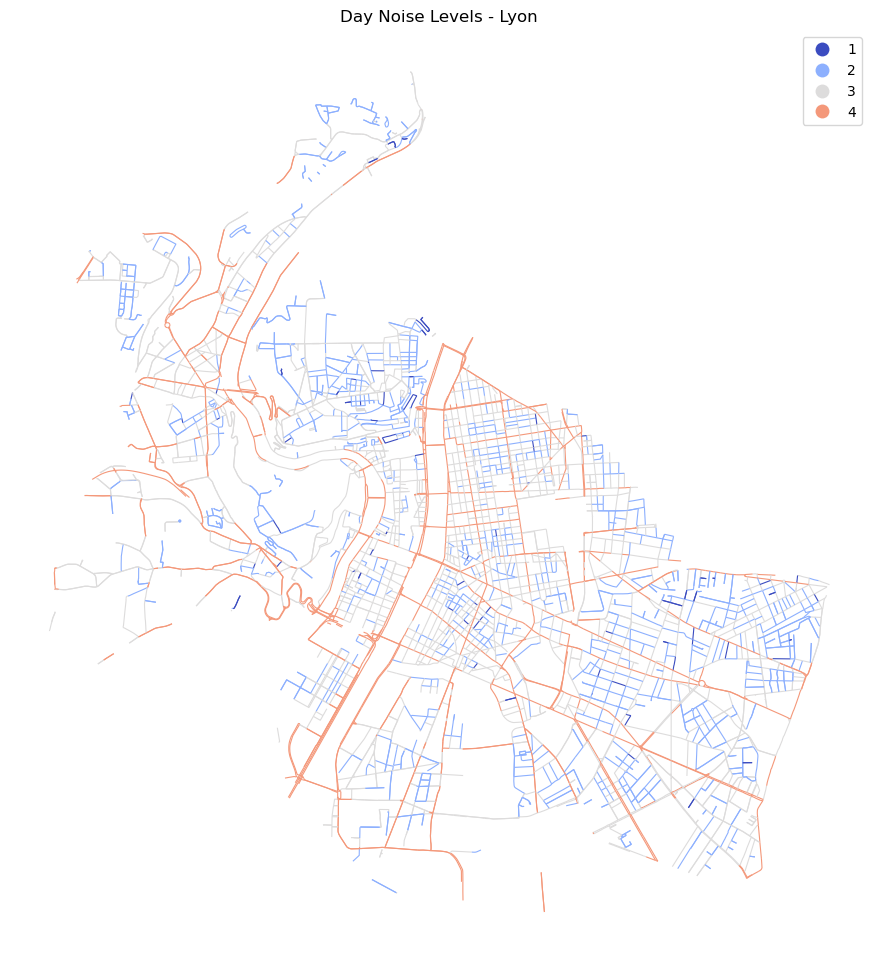

In [14]:
noise_roads['noise_day'] = noise_roads["noise_day"].astype("category")
ax = noise_roads.plot(cmap="coolwarm", column='noise_day', categorical=True, linewidth=0.8, legend=True, figsize=(12, 12), vmin=0, vmax=4)
ax.set_title('Day Noise Levels - Lyon')
ax.set_axis_off()

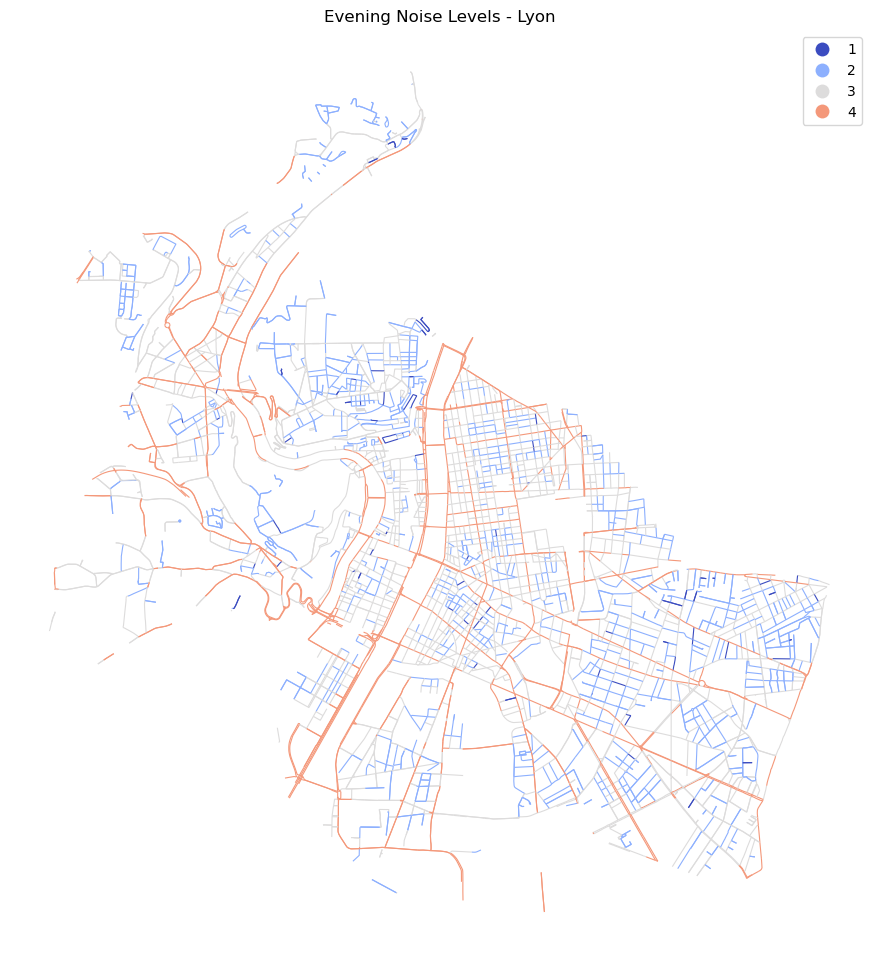

In [15]:
ax = noise_roads.plot(cmap="coolwarm", column='noise_evening', categorical=True, linewidth=0.8, legend=True, figsize=(12, 12), vmin=0, vmax=4)
ax.set_title('Evening Noise Levels - Lyon')
ax.set_axis_off()

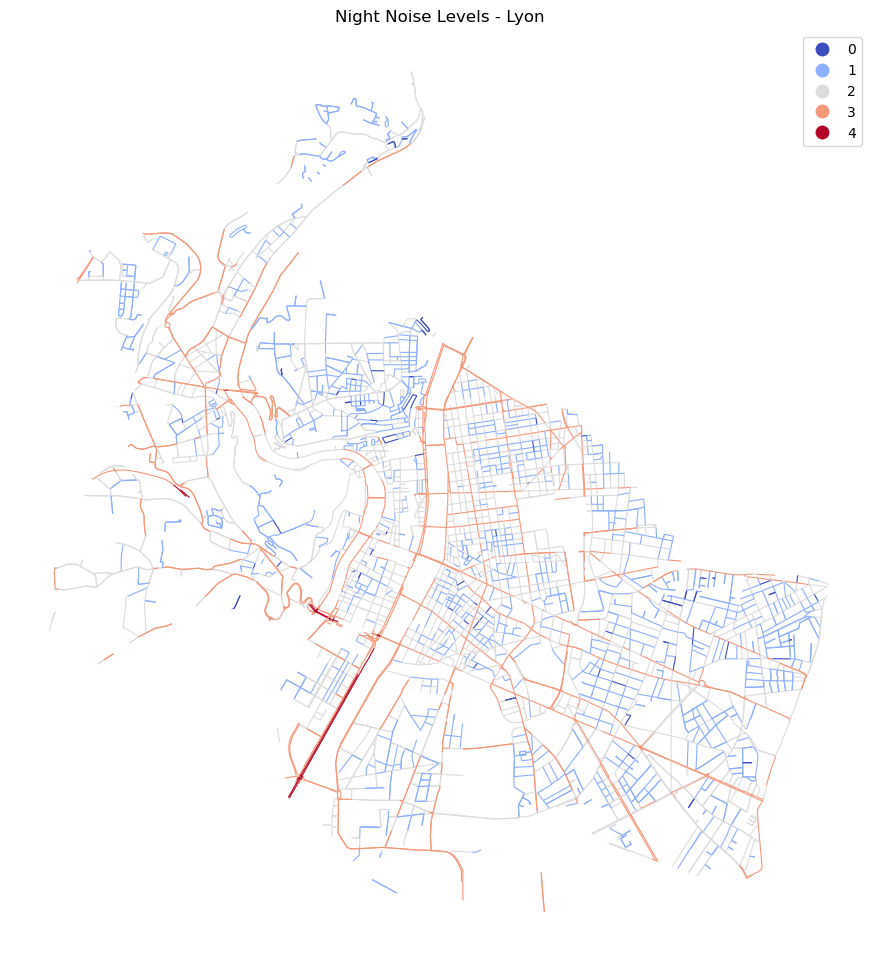

In [16]:
ax = noise_roads.plot(cmap="coolwarm", column='noise_night', categorical=True, linewidth=0.8, legend=True, figsize=(12, 12), vmin=0, vmax=4)
ax.set_title('Night Noise Levels - Lyon')
ax.set_axis_off()

## Convert category to numerical feature

In [17]:
noise_roads['road_category'] = noise_roads['highway']
noise_roads['road_category'].value_counts()

road_category
residential      3991
tertiary         1094
primary           984
secondary         771
living_street     307
trunk              12
Name: count, dtype: int64

In [18]:
category_map = {
    'trunk': 1,
    'primary': 2,
    'secondary': 3,
    'tertiary': 4,
    'residential': 5,
    'living_street': 6
}

noise_roads['category_code'] = noise_roads['highway'].map(category_map)
noise_roads.head()

,osmid,highway,maxspeed,name,oneway,reversed,length,geometry,lanes,bridge,...,segment_id,is_tunnel,db_day,db_evening,db_night,noise_day,noise_evening,noise_night,road_category,category_code
0,120412669,residential,30,Rue Professeur Morat,False,True,7.253513,"LINESTRING (845997.628 6516651.325, 845991.441...",NaN,NaN,...,143403_21714981_0,0,75.146004,75.146004,64.759003,4,4,3,residential,5
1,120412669,residential,30,Rue Professeur Morat,False,False,25.012168,"LINESTRING (845997.628 6516651.325, 846002.531...",NaN,NaN,...,143403_21718288_0,0,70.842003,70.842003,60.486000,4,4,3,residential,5
2,521119804,primary,50,Avenue Jean Mermoz,True,False,102.443140,"LINESTRING (845997.628 6516651.325, 845973.161...",1,NaN,...,143403_143408_0,0,74.252998,74.252998,63.867001,4,4,3,primary,2
3,4087153,residential,30,Rue Édouard Nieuport,True,False,309.504085,"LINESTRING (845903.034 6516691.032, 845903.393...",2,NaN,...,143408_21718264_0,0,60.342999,60.342999,49.969002,3,3,1,residential,5
4,521119804,primary,50,Avenue Jean Mermoz,True,False,93.181541,"LINESTRING (845903.034 6516691.032, 845895.35 ...",1,NaN,...,143408_932576340_0,0,73.386002,73.386002,63.000999,4,4,3,primary,2


## Calculate distance to the closest road of each category

In [19]:
# Ensure unique index and keep a stable row id for repeated nearest joins
noise_roads = noise_roads.reset_index(drop=True).copy()
noise_roads['road_idx'] = noise_roads.index

# Drop join helper columns if they exist to avoid conflicts in repeated runs
join_helper_cols = ['index_right'] + [col for col in noise_roads.columns if col.startswith('dist_to_')]
noise_roads = noise_roads.drop(columns=[col for col in join_helper_cols if col in noise_roads.columns], errors='ignore')

road_categories = ['trunk', 'primary', 'secondary', 'tertiary', 'residential', 'living_street']

for category in road_categories:
    category_roads = noise_roads[noise_roads['highway'] == category][['geometry']].copy()
    distance_col = f'dist_to_{category}'

    if category_roads.empty:
        noise_roads[distance_col] = pd.NA
        continue

    nearest_category = noise_roads[['road_idx', 'geometry']].sjoin_nearest(
        category_roads,
        how='left',
        distance_col=distance_col
    )
    min_distances = nearest_category.groupby('road_idx')[distance_col].min()
    noise_roads[distance_col] = noise_roads['road_idx'].map(min_distances)

noise_roads = noise_roads.drop(columns=['road_idx']).drop_duplicates(subset='segment_id', keep='first')
noise_roads.head()

,osmid,highway,maxspeed,name,oneway,reversed,length,geometry,lanes,bridge,...,noise_evening,noise_night,road_category,category_code,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,dist_to_living_street
0,120412669,residential,30,Rue Professeur Morat,False,True,7.253513,"LINESTRING (845997.628 6516651.325, 845991.441...",NaN,NaN,...,4,3,residential,5,4001.051496,0.0,366.150625,98.073488,0.0,213.549543
1,120412669,residential,30,Rue Professeur Morat,False,False,25.012168,"LINESTRING (845997.628 6516651.325, 846002.531...",NaN,NaN,...,4,3,residential,5,4005.447822,0.0,373.342535,98.501227,0.0,215.068457
2,521119804,primary,50,Avenue Jean Mermoz,True,False,102.443140,"LINESTRING (845997.628 6516651.325, 845973.161...",1,NaN,...,4,3,primary,2,3902.900937,0.0,323.583327,98.501227,0.0,215.068457
3,4087153,residential,30,Rue Édouard Nieuport,True,False,309.504085,"LINESTRING (845903.034 6516691.032, 845903.393...",2,NaN,...,3,1,residential,5,3812.886444,0.0,323.583327,0.000000,0.0,293.111426
4,521119804,primary,50,Avenue Jean Mermoz,True,False,93.181541,"LINESTRING (845903.034 6516691.032, 845895.35 ...",1,NaN,...,4,3,primary,2,3809.626885,0.0,274.800044,108.501123,0.0,293.111426


In [20]:
# Summarize distance-to-category features
distance_cols = [col for col in noise_roads.columns if col.startswith('dist_to_')]
noise_roads[distance_cols].describe()

,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,dist_to_living_street
count,7159.000000,7159.000000,7159.000000,7159.000000,7159.000000,7159.000000
mean,2253.718639,272.101664,260.026679,200.903424,14.920884,307.481901
std,1324.750657,296.573413,277.178703,239.082870,54.725362,294.117973
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1172.000452,17.188954,39.077329,0.000000,0.000000,99.381500
50%,2176.490062,177.030752,184.365499,127.863826,0.000000,233.258265
75%,3153.332257,416.892678,389.991044,297.582328,0.000000,416.187246
max,5540.294687,1605.042273,1547.591626,1521.104186,964.999860,1740.205236


## Calculate distance to major road

In [21]:
# Filter target roads
target_categories = ['trunk', 'primary', 'secondary' ]
target_roads = noise_roads[noise_roads['highway'].isin(target_categories)].copy()

# Ensure unique index
noise_roads = noise_roads.reset_index(drop=True)
target_roads = target_roads.reset_index(drop=True)

# Drop 'index_right' if it exists to avoid conflicts with sjoin_nearest
if 'index_right' in noise_roads.columns:
    noise_roads = noise_roads.drop(columns=['index_right'])

# Spatial join: each noise road gets its nearest target road (no duplication)
noise_roads = noise_roads.sjoin_nearest(
    target_roads[['geometry']], how='left', distance_col='dist_to_main'
)
noise_roads.fillna(0) #fillna(0) to replace any NaN values with 0
noise_roads = noise_roads.drop_duplicates(subset='segment_id', keep='first')
noise_roads.head()

,osmid,highway,maxspeed,name,oneway,reversed,length,geometry,lanes,bridge,...,road_category,category_code,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,dist_to_living_street,index_right,dist_to_main
0,120412669,residential,30,Rue Professeur Morat,False,True,7.253513,"LINESTRING (845997.628 6516651.325, 845991.441...",NaN,NaN,...,residential,5,4001.051496,0.0,366.150625,98.073488,0.0,213.549543,167,0.0
1,120412669,residential,30,Rue Professeur Morat,False,False,25.012168,"LINESTRING (845997.628 6516651.325, 846002.531...",NaN,NaN,...,residential,5,4005.447822,0.0,373.342535,98.501227,0.0,215.068457,1599,0.0
2,521119804,primary,50,Avenue Jean Mermoz,True,False,102.443140,"LINESTRING (845997.628 6516651.325, 845973.161...",1,NaN,...,primary,2,3902.900937,0.0,323.583327,98.501227,0.0,215.068457,1599,0.0
3,4087153,residential,30,Rue Édouard Nieuport,True,False,309.504085,"LINESTRING (845903.034 6516691.032, 845903.393...",2,NaN,...,residential,5,3812.886444,0.0,323.583327,0.000000,0.0,293.111426,0,0.0
4,521119804,primary,50,Avenue Jean Mermoz,True,False,93.181541,"LINESTRING (845903.034 6516691.032, 845895.35 ...",1,NaN,...,primary,2,3809.626885,0.0,274.800044,108.501123,0.0,293.111426,0,0.0


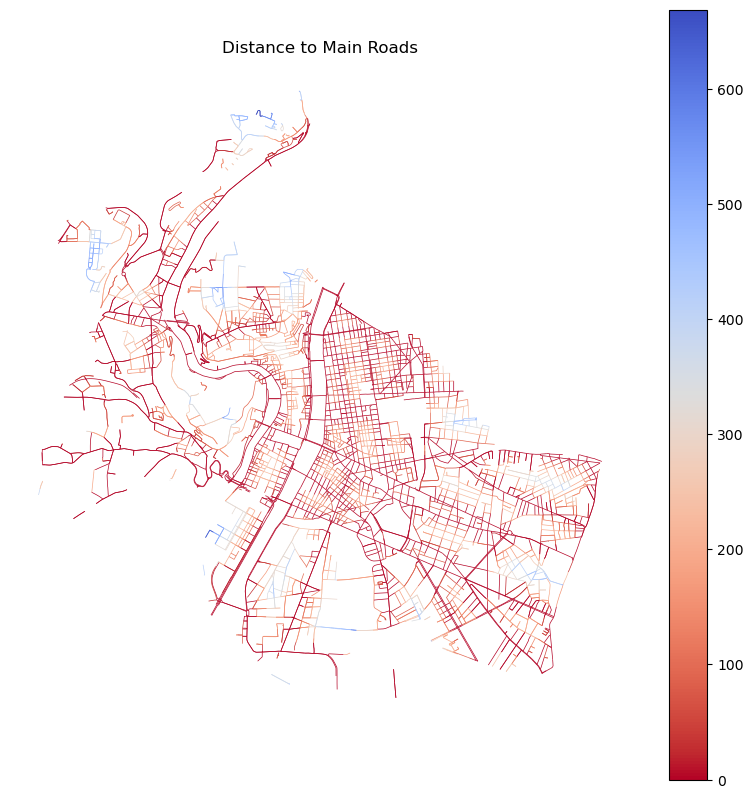

In [22]:
# Plot Distance to Main Roads
ax = noise_roads.plot(column='dist_to_main', cmap='coolwarm_r', linewidth=0.5, legend=True, figsize=(10, 10))
ax.set_title('Distance to Main Roads')
ax.set_axis_off()

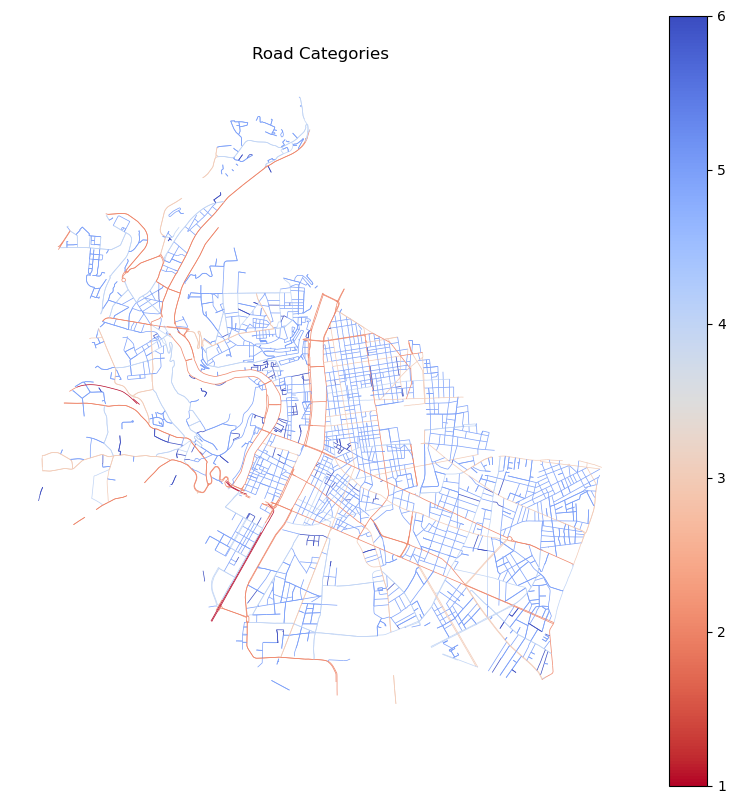

In [23]:
# Plot Road Categories
ax = noise_roads.plot(column='category_code', cmap='coolwarm_r', linewidth=0.5, legend=True, figsize=(10, 10))
ax.set_title('Road Categories')
ax.set_axis_off()

In [24]:
noise_roads.head()

,osmid,highway,maxspeed,name,oneway,reversed,length,geometry,lanes,bridge,...,road_category,category_code,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,dist_to_living_street,index_right,dist_to_main
0,120412669,residential,30,Rue Professeur Morat,False,True,7.253513,"LINESTRING (845997.628 6516651.325, 845991.441...",NaN,NaN,...,residential,5,4001.051496,0.0,366.150625,98.073488,0.0,213.549543,167,0.0
1,120412669,residential,30,Rue Professeur Morat,False,False,25.012168,"LINESTRING (845997.628 6516651.325, 846002.531...",NaN,NaN,...,residential,5,4005.447822,0.0,373.342535,98.501227,0.0,215.068457,1599,0.0
2,521119804,primary,50,Avenue Jean Mermoz,True,False,102.443140,"LINESTRING (845997.628 6516651.325, 845973.161...",1,NaN,...,primary,2,3902.900937,0.0,323.583327,98.501227,0.0,215.068457,1599,0.0
3,4087153,residential,30,Rue Édouard Nieuport,True,False,309.504085,"LINESTRING (845903.034 6516691.032, 845903.393...",2,NaN,...,residential,5,3812.886444,0.0,323.583327,0.000000,0.0,293.111426,0,0.0
4,521119804,primary,50,Avenue Jean Mermoz,True,False,93.181541,"LINESTRING (845903.034 6516691.032, 845895.35 ...",1,NaN,...,primary,2,3809.626885,0.0,274.800044,108.501123,0.0,293.111426,0,0.0


## Export Lyon noise streets layer

LYO_noise_streets.gpkg (layer `noise_streets`) in `deployment/Lyon/layers/` — all
filtered street segments with their dB values and noise classes.

In [25]:
export_cols = ['segment_id', 'highway', 'name', 'length',
               'db_day', 'db_evening', 'db_night',
               'noise_day', 'noise_evening', 'noise_night', 'geometry']
export_gdf = noise_roads[[c for c in export_cols if c in noise_roads.columns]].copy()
export_gdf['name'] = export_gdf['name'].astype(str)
export_gdf['noise_day'] = export_gdf['noise_day'].astype(int)

out_gpkg = os.path.join(_layers_dir, 'LYO_noise_streets.gpkg')
export_gdf.to_file(out_gpkg, layer='noise_streets', driver='GPKG')
print('Exported:', out_gpkg)
print('Segments:', len(export_gdf))

Exported: C:\Users\giofo\Desktop\ARCHIVIO\MASTERS\MACAD\2_MACAD\0_MACAD DRIVE\AIA\DATA ENCODING -- SUBMISSIONS\ML-Noise-Prediction\deployment\Lyon\layers\LYO_noise_streets.gpkg
Segments: 7159


## Create data frame

In [26]:
dataset = pd.DataFrame({
    "road_id": noise_roads['segment_id'],
    "noise_day": noise_roads['noise_day'].astype(int),
    "noise_evening": noise_roads['noise_evening'],
    "noise_night": noise_roads['noise_night'],
    "road_category": noise_roads['category_code'],
    **{f'dist_to_{c}': noise_roads[f'dist_to_{c}'] for c in road_categories},
}).fillna(0)

dataset = dataset.drop_duplicates(subset='road_id', keep='first')
dataset.head()

,road_id,noise_day,noise_evening,noise_night,road_category,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,dist_to_living_street
0,143403_21714981_0,4,4,3,5,4001.051496,0.0,366.150625,98.073488,0.0,213.549543
1,143403_21718288_0,4,4,3,5,4005.447822,0.0,373.342535,98.501227,0.0,215.068457
2,143403_143408_0,4,4,3,2,3902.900937,0.0,323.583327,98.501227,0.0,215.068457
3,143408_21718264_0,3,3,1,5,3812.886444,0.0,323.583327,0.000000,0.0,293.111426
4,143408_932576340_0,4,4,3,2,3809.626885,0.0,274.800044,108.501123,0.0,293.111426


## Check correlation with noise

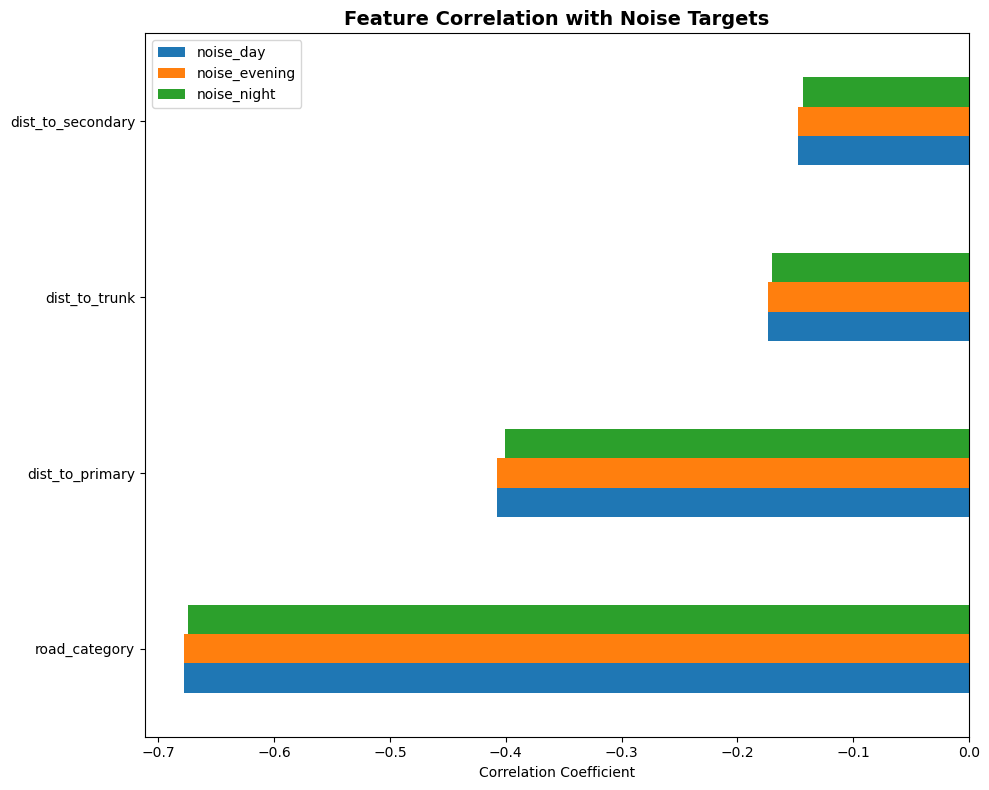

                   noise_day  noise_evening  noise_night
dist_to_secondary  -0.147319      -0.147319    -0.142929
dist_to_trunk      -0.173196      -0.173196    -0.169803
dist_to_primary    -0.407795      -0.407795    -0.400565
road_category      -0.677531      -0.677531    -0.674346


In [27]:
# Extract correlations with noise predictions
dataset_filtered = dataset[['noise_day', 'noise_evening', 'noise_night', 'road_category',
                            'dist_to_trunk', 'dist_to_primary', 'dist_to_secondary']]
target_cols = ['noise_day', 'noise_evening', 'noise_night']
feature_correlation = dataset_filtered.corr(method = 'spearman')[target_cols].drop(target_cols)

# Sort by absolute correlation
feature_correlation_sorted = feature_correlation.abs().sort_values('noise_day', ascending=False)

# Plot bar chart
fig, ax = plt.subplots(figsize=(10, 8))
feature_correlation.loc[feature_correlation_sorted.index].plot(kind='barh', ax=ax)
ax.set_title('Feature Correlation with Noise Targets', fontsize=14, fontweight='bold')
ax.set_xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

print(feature_correlation.sort_values('noise_day', ascending=False))

## Export dataset to CSV

In [28]:
output_dir = "data"
os.makedirs(output_dir, exist_ok=True)
dataset.to_csv(os.path.join(output_dir, "osm_roads_noise_class.csv"), index=False)
print("Exported osm_roads_noise_class.csv")

Exported osm_roads_noise_class.csv
